Notebook 4

In [89]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import cv2

import torch
import torch.nn as nn
from torchvision import models, transforms
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision.models import ResNet18_Weights


from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [90]:
if torch.cuda.is_available():
    device_name = "cuda"
elif torch.backends.mps.is_available():
    device_name = "mps"
else:
    device_name = "cpu"
    
print(f'Using device: {device_name}')
device = torch.device(device_name)

Using device: mps


**Load Keypoints LSTM Model**

In [91]:
# Load keypoints LSTM model (X,Y,Z version)
ckpt_path = "models/keypoints_division_classifier_xyz.pth"
ckpt = torch.load(ckpt_path, map_location=device_name, weights_only=False)

id2label = ckpt["id2label"]
label2id = ckpt["label2id"]
sequence_length = ckpt["sequence_length"]
input_size = ckpt["input_size"]
num_classes = len(id2label)

# Rebuild the model
class KeypointsLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                           batch_first=True, dropout=0.3 if num_layers > 1 else 0)
        self.fc = nn.Linear(hidden_size, num_classes)
        
    def forward(self, x):
        lstm_out, (h_n, c_n) = self.lstm(x)
        out = self.fc(h_n[-1])
        return out

model = KeypointsLSTM(input_size=input_size, hidden_size=128, num_layers=2, num_classes=num_classes)
model.load_state_dict(ckpt["state_dict"])
model = model.to(device_name).eval()

print("Loaded Keypoints LSTM model with classes:", id2label)
print(f"Sequence length: {sequence_length} frames")
print(f"Input size: {input_size} (includes Z-axis)")
print(f"CV performance: {ckpt.get('cv_mean_acc', 'N/A'):.3f} ± {ckpt.get('cv_std_acc', 'N/A'):.3f}")

Loaded Keypoints LSTM model with classes: {0: 'advanced', 1: 'allstar', 2: 'champion', 3: 'intermediate', 4: 'novice'}
Sequence length: 32 frames
Input size: 99 (includes Z-axis)
CV performance: 0.350 ± 0.087


**Load Keypoints Test Data**

In [92]:
# Load keypoints test data
labels_df = pd.read_csv("../data/hp.csv")

keypoints_sequences = []
true_labels = []

KEYPOINTS_DIR = Path("../data/keypoints_1")

for idx, row in labels_df.iterrows():
    folder_name = f"{row['division']}_{row['id']}"
    keypoints_file = KEYPOINTS_DIR / row['division'] / folder_name / "keypoints.npy"
    
    if keypoints_file.exists():
        keypoints = np.load(keypoints_file)
        keypoints_sequences.append(keypoints)
        true_labels.append(label2id[row['division']])
    else:
        print(f"⚠ Missing keypoints for: {row['division']} {row['id']}")
        
print(f"Loaded {len(keypoints_sequences)} keypoints sequences from {len(labels_df)} videos")

⚠ Missing keypoints for: advanced 11
Loaded 19 keypoints sequences from 20 videos


**Preprocess Keypoints for Prediction**

In [93]:
def preprocess_keypoints_sequence(keypoints, target_length):
    """Preprocess keypoints sequence for model input"""
    keypoints = keypoints.astype(np.float32)  # (frames, keypoints, 4)
    
    # Use X,Y,Z coordinates (first 3 dimensions): (frames, keypoints, 3)
    keypoints = keypoints[:, :, :3]
    
    # Flatten keypoints: (frames, keypoints*3)
    keypoints = keypoints.reshape(keypoints.shape[0], -1)
    
    if keypoints.shape[0] >= target_length:
        # Take consecutive frames from the middle
        start_idx = (keypoints.shape[0] - target_length) // 2
        keypoints = keypoints[start_idx:start_idx + target_length]
    else:
        # Pad with repeat
        repeat_times = (target_length + keypoints.shape[0] - 1) // keypoints.shape[0]
        keypoints = np.tile(keypoints, (repeat_times, 1))[:target_length]
    
    return torch.tensor(keypoints).unsqueeze(0)  # Add batch dimension

print(f"Preprocessing {len(keypoints_sequences)} sequences...")
print(f"Target sequence length: {sequence_length}")
print(f"Input size: {input_size} (includes Z-axis)")

Preprocessing 19 sequences...
Target sequence length: 32
Input size: 99 (includes Z-axis)


**Making Predictions with Keypoints**

In [94]:
# Make predictions on keypoints data
preds = []
confidences = []

with torch.no_grad():
    for keypoints_seq in keypoints_sequences:
        x = preprocess_keypoints_sequence(keypoints_seq, sequence_length).to(device_name)
        logits = model(x)
        probs = torch.softmax(logits, dim=1)
        
        pred = logits.argmax(1).item()
        conf = probs.max().item()
        
        preds.append(pred)
        confidences.append(conf)

preds = np.array(preds)
confidences = np.array(confidences)
true_labels = np.array(true_labels)

print(f"Predictions: {preds}")
print(f"True labels: {true_labels}")
print(f"Average confidence: {np.mean(confidences):.3f}")

Predictions: [3 4 4 0 3 0 3 4 1 1 3 1 0 0 1 0 3 0 0]
True labels: [4 4 4 3 3 0 0 3 3 0 0 3 0 0 3 3 3 3 3]
Average confidence: 0.646


Confusion Matrix

<Figure size 600x500 with 0 Axes>

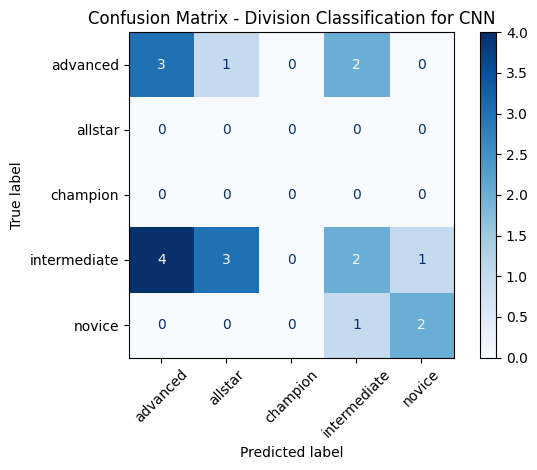

In [95]:

classes = sorted(id2label.keys()) 
cm = confusion_matrix(true_labels, preds, labels=classes)

display_labels = [id2label[c] for c in classes]

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
plt.figure(figsize=(6,5))

disp.plot(cmap='Blues', values_format="d", xticks_rotation=45)

if cm.max() == cm.min():
    disp.im_.set_clim(0, cm.max() + 1)

plt.title("Confusion Matrix - Division Classification for CNN")
plt.tight_layout()
plt.show()

Misclassified Examples

number of misclassified examples: 12


<Figure size 1500x500 with 0 Axes>

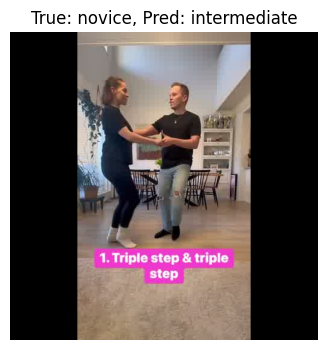

In [96]:
mis_idx = [i for i in range(len(preds)) if preds[i] != true_labels[i]]

print("number of misclassified examples:", len(mis_idx))

def show_misclassified(n=1):
    plt.figure(figsize=(15, 5))
    for i in mis_idx[:n]:
        img = Image.open(image_paths[i]).convert("RGB")
        plt.figure(figsize=(4,4))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"True: {id2label[true_labels[i]]}, Pred: {id2label[preds[i]]}")
        plt.show()

show_misclassified()
       

**LSTM Analysis - Temporal Importance Visualization**

In [97]:
# For LSTM models, we analyze temporal importance instead of spatial heatmaps
def analyze_temporal_importance(keypoints_seq, model, sequence_length):
    """Analyze which time steps are most important for the LSTM's decision"""
    model.eval()
    
    # Preprocess the sequence
    x = preprocess_keypoints_sequence(keypoints_seq, sequence_length).to(device_name)
    
    # Get LSTM outputs for each time step
    with torch.no_grad():
        # Get LSTM hidden states for all time steps
        lstm_out, (h_n, c_n) = model.lstm(x)
        
        # Get classification weights
        fc_weights = model.fc.weight.data  # (num_classes, hidden_size)
        
        # Calculate importance scores for each time step
        # Importance = |output · weight| for the predicted class
        pred_class = model(x).argmax(1).item()
        class_weights = fc_weights[pred_class]  # (hidden_size,)
        
        # Calculate importance per time step
        importance_scores = []
        for t in range(lstm_out.shape[1]):  # for each time step
            timestep_output = lstm_out[0, t, :]  # (hidden_size,)
            importance = torch.abs(torch.dot(timestep_output, class_weights)).item()
            importance_scores.append(importance)
        
        # Normalize importance scores
        importance_scores = np.array(importance_scores)
        importance_scores = importance_scores / (importance_scores.max() + 1e-8)
        
    return importance_scores

def plot_temporal_importance(keypoints_seq, importance_scores, title="Temporal Importance"):
    """Plot the importance of each time step"""
    plt.figure(figsize=(15, 4))
    
    plt.subplot(1, 3, 1)
    plt.plot(importance_scores, 'b-', linewidth=2)
    plt.xlabel('Time Step')
    plt.ylabel('Importance Score')
    plt.title(title)
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 3, 2)
    # Show X,Y trajectory (first keypoint)
    keypoints_xy = keypoints_seq[:, :, :2]  # Use only x,y for trajectory
    if keypoints_xy.shape[1] > 0:
        plt.plot(keypoints_xy[:, 0, 0], keypoints_xy[:, 0, 1], 'r-o', markersize=3)
        plt.xlabel('X Coordinate')
        plt.ylabel('Y Coordinate')
        plt.title('Keypoint 0 Trajectory (X,Y)')
        plt.axis('equal')
        plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 3, 3)
    # Show Z movement (first keypoint)
    keypoints_z = keypoints_seq[:, :, 2]  # Z coordinate only
    if keypoints_z.shape[1] > 0:
        plt.plot(keypoints_z[:, 0], 'g-o', markersize=3)
        plt.xlabel('Time Step')
        plt.ylabel('Z Coordinate')
        plt.title('Keypoint 0 Z Movement')
        plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("Temporal importance analysis functions ready (with Z-axis visualization)!")

Temporal importance analysis functions ready (with Z-axis visualization)!


**Visualize Temporal Importance for Examples**

=== CORRECT PREDICTION ANALYSIS ===
Example 1: True=novice, Pred=novice, Conf=0.455


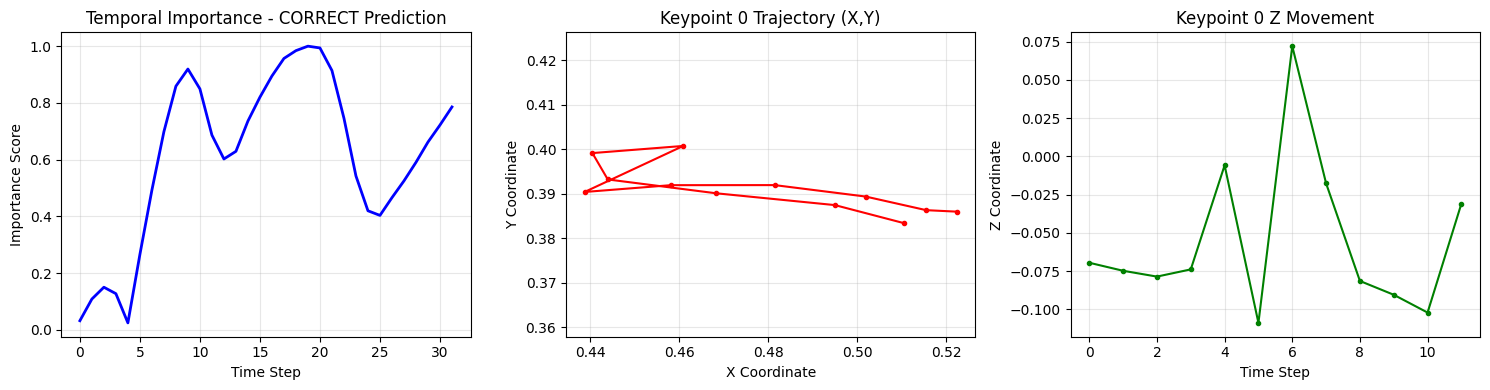


=== INCORRECT PREDICTION ANALYSIS ===
Example 0: True=novice, Pred=intermediate, Conf=0.612


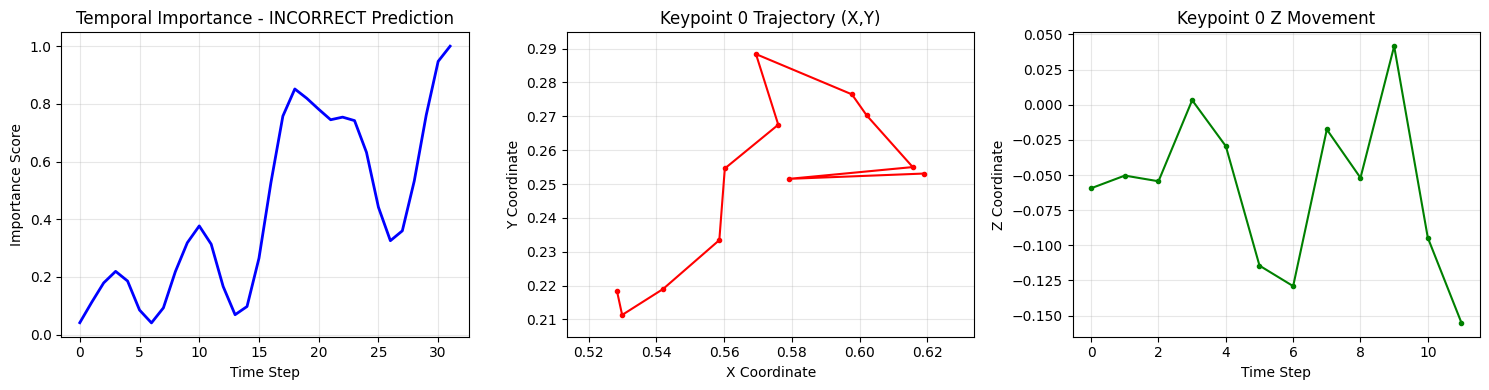

In [98]:
def analyze_example(idx):
    """Analyze temporal importance for a specific example"""
    keypoints_seq = keypoints_sequences[idx]
    true_label = id2label[true_labels[idx]]
    pred_label = id2label[preds[idx]]
    confidence = confidences[idx]
    
    print(f"Example {idx}: True={true_label}, Pred={pred_label}, Conf={confidence:.3f}")
    
    # Analyze temporal importance
    importance_scores = analyze_temporal_importance(keypoints_seq, model, sequence_length)
    
    # Plot results
    is_correct = true_labels[idx] == preds[idx]
    status = "CORRECT" if is_correct else "INCORRECT"
    plot_temporal_importance(keypoints_seq, importance_scores, 
                           f"Temporal Importance - {status} Prediction")

# Analyze a correct prediction
correct_indices = [i for i in range(len(preds)) if preds[i] == true_labels[i]]
if correct_indices:
    print("=== CORRECT PREDICTION ANALYSIS ===")
    analyze_example(correct_indices[0])

# Analyze an incorrect prediction  
incorrect_indices = [i for i in range(len(preds)) if preds[i] != true_labels[i]]
if incorrect_indices:
    print("\n=== INCORRECT PREDICTION ANALYSIS ===")
    analyze_example(incorrect_indices[0])

**Analyze Multiple Examples**

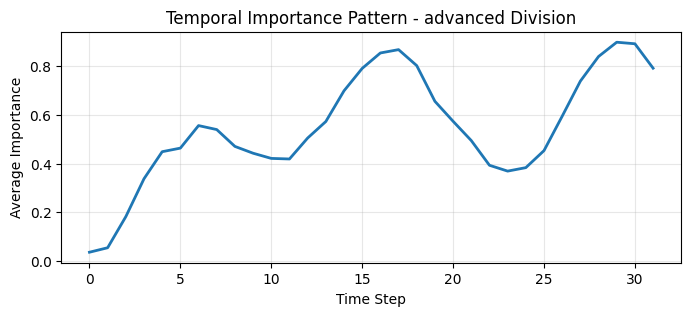

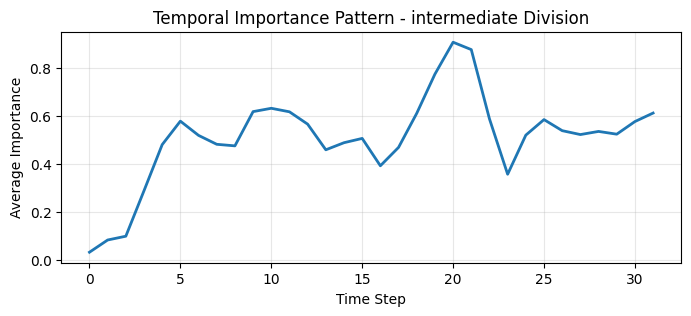

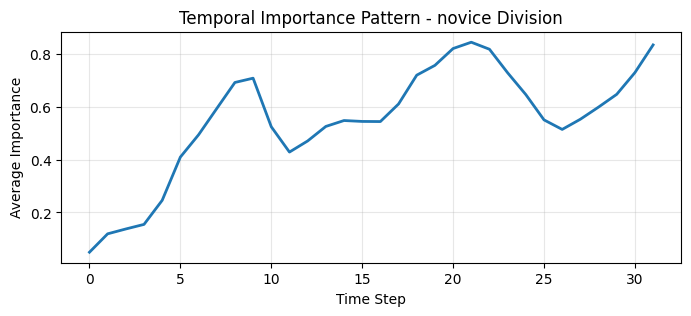

Division-specific temporal analysis complete!


In [99]:
# Analyze temporal patterns for different divisions
division_analysis = {}

for division in id2label.values():
    division_indices = [i for i in range(len(true_labels)) if id2label[true_labels[i]] == division]
    if division_indices:
        # Collect importance scores for this division
        all_importance = []
        for idx in division_indices[:3]:  # Analyze first 3 examples per division
            importance = analyze_temporal_importance(keypoints_sequences[idx], model, sequence_length)
            all_importance.append(importance)
        
        # Average importance pattern for this division
        avg_importance = np.mean(all_importance, axis=0)
        division_analysis[division] = avg_importance
        
        plt.figure(figsize=(8, 3))
        plt.plot(avg_importance, linewidth=2, label=f'{division} (n={len(division_indices)})')
        plt.xlabel('Time Step')
        plt.ylabel('Average Importance')
        plt.title(f'Temporal Importance Pattern - {division} Division')
        plt.grid(True, alpha=0.3)
        plt.show()

print("Division-specific temporal analysis complete!")

**Division-Level Performance Analysis**

=== Division-Level Performance ===
advanced: 0.500 accuracy (6 samples)
intermediate: 0.200 accuracy (10 samples)
novice: 0.667 accuracy (3 samples)


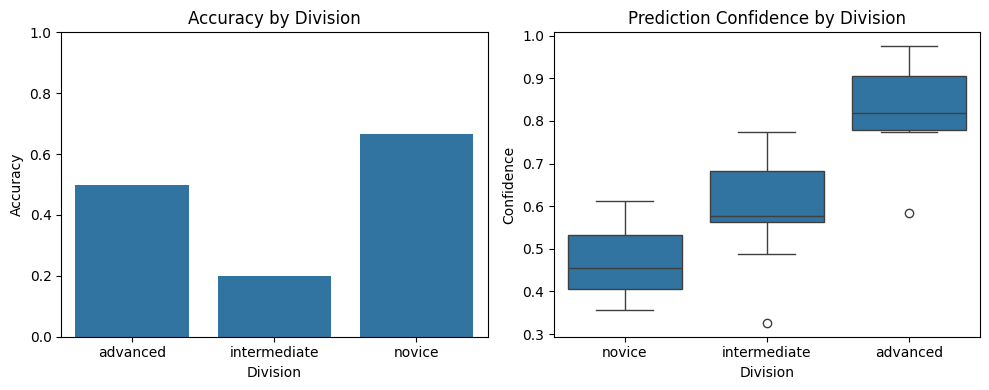


=== Overall Performance ===
Overall Accuracy: 0.368
Average Confidence: 0.646


In [100]:
# Create a DataFrame for sequence-level results
results_df = pd.DataFrame({
    "true_label": true_labels,
    "pred": preds,
    "confidence": confidences,
    "sequence_idx": range(len(preds))
})

# Add division names
results_df["true_division"] = results_df["true_label"].apply(lambda x: id2label[x])
results_df["pred_division"] = results_df["pred"].apply(lambda x: id2label[x])
results_df["correct"] = results_df["true_label"] == results_df["pred"]

# Calculate accuracy per division
division_acc = results_df.groupby("true_division")["correct"].mean()
division_counts = results_df.groupby("true_division").size()

print("=== Division-Level Performance ===")
for division in division_acc.index:
    acc = division_acc[division]
    count = division_counts[division]
    print(f"{division}: {acc:.3f} accuracy ({count} samples)")

plt.figure(figsize=(10, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
sns.barplot(x=division_acc.index, y=division_acc.values)
plt.title("Accuracy by Division")
plt.ylabel("Accuracy")
plt.xlabel("Division")
plt.ylim(0, 1)

# Confidence plot
plt.subplot(1, 2, 2)
sns.boxplot(data=results_df, x="true_division", y="confidence")
plt.title("Prediction Confidence by Division")
plt.ylabel("Confidence")
plt.xlabel("Division")

plt.tight_layout()
plt.show()

print("\n=== Overall Performance ===")
overall_acc = results_df["correct"].mean()
avg_confidence = results_df["confidence"].mean()
print(f"Overall Accuracy: {overall_acc:.3f}")
print(f"Average Confidence: {avg_confidence:.3f}")

<!-- TO DO : add interpretations of results after adding more data -->